untuk mengerjakan skripsi penerjemah bahasa isyarat sibi mengunakan cnn dan lstm

# import library

In [ ]:
!pip uninstall -y mediapipe protobuf
!pip install mediapipe==0.10.14

Found existing installation: protobuf 5.29.5
Uninstalling protobuf-5.29.5:
  Successfully uninstalled protobuf-5.29.5
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.7/35.7 MB 74.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.2/295.2 kB 34.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
grain 0.2.15 requires protobuf>=5.28.3, but you have protobuf 4.25.9 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 4.25.9 which is incompatible.
opentelemetry-proto 1.37.0 requires protobuf<7.0,>=5.0, but you have protobuf 4.25.9 which is incompatible.
ydf 0.14.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 4.25.9 which is incompatible.


In [ ]:
import cv2
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import mediapipe as mp
from tensorflow.keras.models import Model
from tensorflow.keras.layers import TimeDistributed, Flatten, LSTM, Dense, Dropout, Input, GlobalAveragePooling2D,BatchNormalization
from tensorflow.keras.applications import Xception
from tensorflow.keras.utils import plot_model
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from IPython.display import Image, display

# Akuisisi Data

## memanggil folder data

In [ ]:
raw_folder_path = '/content/drive/MyDrive/raw'

# Periksa apakah folder tersebut ada
if os.path.exists(raw_folder_path):
    print(f"Folder 'raw' ditemukan di: {raw_folder_path}")
    print("Isi folder 'raw' (urutan abjad):")
    for item in sorted(os.listdir(raw_folder_path)):
        print(item)
else:
    print(f"Folder 'raw' tidak ditemukan di: {raw_folder_path}")
    print("Pastikan folder 'raw' ada di Google Drive Anda dan path yang diberikan sudah benar.")

Folder 'raw' ditemukan di: /content/drive/MyDrive/raw
Isi folder 'raw' (urutan abjad):
akhiran-an
akhiran-i
akhiran-kan
akhiran-man
akhiran-nya
akhiran-ti
akhiran-wan
akhiran-wati
apa
awalan-ber
awalan-di
awalan-ke
awalan-me
awalan-pe
awalan-se
awalan-ter
baca
bagaimana
balai
bantu
bawa
beli
benar
berapa
bicara
bisa
buka
buku
cari
datang
dengar
desa
dia
dosen
duduk
gedung
guna
guru
hari
ingat
ini
itu
jalan
jalan-jalan
jawab
kamar
kami
kamu
kapan
keluarga
kendaraan
kerja
kita
kursi
lihat
lupa
makan
malam
mana
mau
meja
mengapa
mereka
minum
motor
mudah
mulai
nanti
nasi
orang
pagi
partikel-kah
partikel-lah
partikel-pun
pasar
pergi
perlu
rumah
salah
satu
saya
sedih
sekarang
sekolah
selamat
selesai
senang
siapa
sore
suka
sulit
tahu
tanya
tas
teh
telepon
teman
tidur
tinggal
toko
tunggu
tutup
uang
waktu


# Processing Data

In [ ]:
root_raw_dir = raw_folder_path
output_root = 'data/processed'

num_frames_to_save = 20
target_size = (160,160)


for label in sorted(os.listdir(root_raw_dir)):

    word_path = os.path.join(root_raw_dir, label)

    if not os.path.isdir(word_path):
        continue

    print(f"Processing label: {label}")

    output_label_dir = os.path.join(output_root, label)

    os.makedirs(output_label_dir, exist_ok=True)

    for video_name in sorted(os.listdir(word_path)):

        if not video_name.lower().endswith('.webm') and not video_name.lower().endswith('.mp4'):
            continue

        video_full_path = os.path.join(word_path, video_name)
        video_base_name = os.path.splitext(video_name)[0]

        cap = cv2.VideoCapture(video_full_path)

        if not cap.isOpened():
            print(f"Gagal membuka video: {video_name}")
            continue

        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

        if total_frames <= 0:
            print(f"Video rusak: {video_name}")
            cap.release()
            continue

        step = max(1, total_frames // num_frames_to_save)

        for i in range(num_frames_to_save):

            frame_id = i * step
            cap.set(cv2.CAP_PROP_POS_FRAMES, frame_id)

            ret, frame = cap.read()
            if not ret:
                break

            frame_res = cv2.resize(frame, target_size)

            h, w = frame_res.shape[:2]
            # crop hanya yang berkestensi .webm
            if video_name.lower().endswith('.webm'):
              crop_top = int(h * 0.25)
              frame_crop = frame_res[crop_top:h, 0:w]
            else:
              frame_crop = frame_res

            # resize lagi agar tetap 160 x 160
            frame_crop = cv2.resize(frame_crop, target_size)

            # Save RGB frame
            rgb_name = f"{video_base_name}_f{i:02d}.jpg"
            cv2.imwrite(os.path.join(output_label_dir, rgb_name), frame_crop)

        cap.release()

        print(f"   selesai: {video_name}")

print("\nSemua video selesai diproses.")

Processing label: akhiran-an
   selesai: Akhiran-An-cam-1.mp4
   selesai: Akhiran-An.webm
   selesai: akhiran-an (1) - Copy.mp4
   selesai: akhiran-an (1).mp4
   selesai: akhiran-an (2) - Copy.mp4
   selesai: akhiran-an (2).mp4
   selesai: akhiran-an (3) - Copy.mp4
   selesai: akhiran-an (3).mp4
   selesai: akhiran-an (4) - Copy.mp4
   selesai: akhiran-an (4).mp4
   selesai: akhiran-an (5) - Copy.mp4
   selesai: akhiran-an (5).mp4
   selesai: akhiran-an (6) - Copy.mp4
   selesai: akhiran-an (6).mp4
   selesai: akhiran-an (7) - Copy.mp4
   selesai: akhiran-an (7).mp4
   selesai: akhiran-an (8) - Copy.mp4
   selesai: akhiran-an (8).mp4
   selesai: akhiran-an (9) - Copy.mp4
   selesai: akhiran-an (9).mp4
   selesai: akhiran-an-1.mp4
   selesai: akhiran-an.mp4
Processing label: akhiran-i
   selesai: Akhiran-I-cam-1.mp4
   selesai: Akhiran-I-cam-4.mp4
   selesai: Akhiran-I.webm
   selesai: akhiran-1 (1) - Copy.mp4
   selesai: akhiran-1 (1).mp4
   selesai: akhiran-1 (2) - Copy.mp4
   selesai

# Data Cleaning

In [ ]:
INPUT_HANDS_DIR = 'data/processed'

def clean_hand_images(input_dir):
    print("Starting hand image cleaning...")
    deleted_count = 0
    total_images = 0

    for label in sorted(os.listdir(input_dir)):
        label_path = os.path.join(input_dir, label)

        if not os.path.isdir(label_path):
            continue

        print(f"  Cleaning label: {label}")

        for img_name in sorted(os.listdir(label_path)):
            total_images += 1
            img_full_path = os.path.join(label_path, img_name)

            try:
                img = cv2.imread(img_full_path)

                # Check for corrupted files
                if img is None:
                    print(f"    Deleting corrupted/unreadable image: {img_full_path}")
                    os.remove(img_full_path)
                    deleted_count += 1
                    continue

                # Check for empty images
                if img.size == 0:
                    print(f"    Deleting empty image: {img_full_path}")
                    os.remove(img_full_path)
                    deleted_count += 1
                    continue

                # Check if the image is mostly black
                if np.mean(img) < 10:
                    print(f"    Deleting mostly black image (likely no hand): {img_full_path}")
                    os.remove(img_full_path)
                    deleted_count += 1
                    continue

            except Exception as e:
                print(f"    Error processing {img_full_path}: {e}. Deleting file.")
                os.remove(img_full_path)
                deleted_count += 1
                continue

    print(f"Cleaning complete. Total images checked: {total_images}, Deleted: {deleted_count}")

clean_hand_images(INPUT_HANDS_DIR)

Starting hand image cleaning...
  Cleaning label: akhiran-an
  Cleaning label: akhiran-i
  Cleaning label: akhiran-kan
  Cleaning label: akhiran-man
  Cleaning label: akhiran-nya
  Cleaning label: akhiran-ti
  Cleaning label: akhiran-wan
  Cleaning label: akhiran-wati
  Cleaning label: apa
  Cleaning label: awalan-ber
  Cleaning label: awalan-di
  Cleaning label: awalan-ke
  Cleaning label: awalan-me
  Cleaning label: awalan-pe
  Cleaning label: awalan-se
  Cleaning label: awalan-ter
  Cleaning label: baca
  Cleaning label: bagaimana
  Cleaning label: balai
  Cleaning label: bantu
  Cleaning label: bawa
  Cleaning label: beli
  Cleaning label: benar
  Cleaning label: berapa
  Cleaning label: bicara
  Cleaning label: bisa
  Cleaning label: buka
  Cleaning label: buku
  Cleaning label: cari
  Cleaning label: datang
  Cleaning label: dengar
  Cleaning label: desa
  Cleaning label: dia
  Cleaning label: dosen
  Cleaning label: duduk
  Cleaning label: gedung
  Cleaning label: guna
  Cleanin

# Ekstraksi fitur

## media pipe

In [ ]:
mp_holistic = mp.solutions.holistic
holistic = mp_holistic.Holistic(
    static_image_mode=True,
    min_detection_confidence=0.5
)

# indeks landmark pose yang relevan: bahu, siku, pergelangan tangan, pinggul
POSE_INDEKS_RELEVAN = [11, 12, 13, 14, 15, 16, 23, 24]

def crop_body_array(image_path, target_size=(160, 160), padding=40):
    img = cv2.imread(image_path)
    if img is None:
        return None

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    results = holistic.process(img_rgb)
    h, w = img.shape[:2]

    x_list, y_list = [], []

    # ambil titik pose yang relevan (badan atas), skip kalau visibility rendah
    if results.pose_landmarks:
        for idx in POSE_INDEKS_RELEVAN:
            lm = results.pose_landmarks.landmark[idx]
            if lm.visibility > 0.3:
                x_list.append(int(lm.x * w))
                y_list.append(int(lm.y * h))

    # tambahkan titik tangan kiri & kanan untuk crop yang lebih presisi
    for hand_landmarks in [results.left_hand_landmarks, results.right_hand_landmarks]:
        if hand_landmarks:
            for lm in hand_landmarks.landmark:
                x_list.append(int(lm.x * w))
                y_list.append(int(lm.y * h))

    if len(x_list) == 0:
        return None  # tidak ada tangan/lengan/badan yang terdeteksi

    x_min = max(min(x_list) - padding, 0)
    y_min = max(min(y_list) - padding, 0)
    x_max = min(max(x_list) + padding, w)
    y_max = min(max(y_list) + padding, h)

    cropped = img[y_min:y_max, x_min:x_max]
    if cropped.shape[0] == 0 or cropped.shape[1] == 0:
        return None
    return cv2.resize(cropped, target_size)


def center_crop_fallback(image_path, target_size=(160, 160)):
    img = cv2.imread(image_path)
    if img is None:
        return None
    h, w = img.shape[:2]
    side = min(h, w)
    y_start = (h - side) // 2
    x_start = (w - side) // 2
    cropped = img[y_start:y_start + side, x_start:x_start + side]
    return cv2.resize(cropped, target_size)


INPUT_BASE_DIR = 'data/processed'
OUTPUT_HANDS_DIR = 'data/hands'   # nama folder bisa tetap sama, isinya saja yang berubah cakupannya
os.makedirs(OUTPUT_HANDS_DIR, exist_ok=True)

for label in sorted(os.listdir(INPUT_BASE_DIR)):
    label_in = os.path.join(INPUT_BASE_DIR, label)
    if not os.path.isdir(label_in):
        continue
    label_out = os.path.join(OUTPUT_HANDS_DIR, label)
    os.makedirs(label_out, exist_ok=True)

    frames_by_video = {}
    for img_name in sorted(os.listdir(label_in)):
        video_base = img_name.rsplit("_f", 1)[0]
        frames_by_video.setdefault(video_base, []).append(img_name)

    for video_base, frame_list in frames_by_video.items():
        frame_list = sorted(frame_list)

        crops = []
        for img_name in frame_list:
            in_path = os.path.join(label_in, img_name)
            crops.append(crop_body_array(in_path))

        detected_count = sum(1 for c in crops if c is not None)

        if detected_count == 0:
            print(f"Peringatan: {video_base} tidak ada badan/tangan terdeteksi, pakai center-crop fallback")
            crops = [center_crop_fallback(os.path.join(label_in, n)) for n in frame_list]
        else:
            last_good = None
            for i in range(len(crops)):
                if crops[i] is not None:
                    last_good = crops[i]
                elif last_good is not None:
                    crops[i] = last_good

            next_good = None
            for i in range(len(crops) - 1, -1, -1):
                if crops[i] is not None:
                    next_good = crops[i]
                elif next_good is not None:
                    crops[i] = next_good

            missing = len(frame_list) - detected_count
            if missing > 0:
                print(f"Info: {video_base} — {missing}/{len(frame_list)} frame diisi dari tetangga terdekat")

        for img_name, crop_img in zip(frame_list, crops):
            out_path = os.path.join(label_out, img_name)
            cv2.imwrite(out_path, crop_img)

/usr/local/lib/python3.12/dist-packages/google/protobuf/symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


Info: Akhiran-An — 1/20 frame diisi dari tetangga terdekat
Info: akhiran-an-1 — 17/20 frame diisi dari tetangga terdekat
Info: Akhiran-I — 2/20 frame diisi dari tetangga terdekat
Info: akhiran-kan-1 — 19/20 frame diisi dari tetangga terdekat
Info: Akhiran-Man — 4/20 frame diisi dari tetangga terdekat
Info: akhiran-man-2 — 4/20 frame diisi dari tetangga terdekat
Info: akhiran-nya-1 — 19/20 frame diisi dari tetangga terdekat
Info: akhiran-ti-1 — 13/20 frame diisi dari tetangga terdekat
Info: akhiran-wan — 19/20 frame diisi dari tetangga terdekat
Info: akhiran-wati-2 — 18/20 frame diisi dari tetangga terdekat
Info: Awalan-Ber — 1/20 frame diisi dari tetangga terdekat
Info: awalan-ber (25) — 1/20 frame diisi dari tetangga terdekat
Info: awalan-ber (26) — 1/20 frame diisi dari tetangga terdekat
Info: awalan-pe-1 — 3/20 frame diisi dari tetangga terdekat
Info: awalan-ke-1 — 17/20 frame diisi dari tetangga terdekat
Info: awalan-me-1 — 13/20 frame diisi dari tetangga terdekat
Info: Awalan-Pe —

# Preparation
menyiapkan data sebelum ke pelatihan

## Preparation RGB

In [ ]:
INPUT_DIR = "data/hands"
OUTPUT_X = "data/prep/X_rgb.npy"
OUTPUT_Y = "data/prep/Y_rgb.npy"

NUM_FRAMES = 20
os.makedirs(os.path.dirname(OUTPUT_X), exist_ok=True)

def prep_rgb():
    X, Y = [], []
    labels = sorted(os.listdir(INPUT_DIR))
    label_map = {label: i for i, label in enumerate(labels)}

    for label in labels:
        label_path = os.path.join(INPUT_DIR, label)
        if not os.path.isdir(label_path):
            continue

        groups = {}
        for img_name in sorted(os.listdir(label_path)):
            key = img_name.rsplit("_f", 1)[0]
            groups.setdefault(key, []).append(img_name)

        for key, frame_files in groups.items():
            frame_files = sorted(frame_files)
            if len(frame_files) < NUM_FRAMES:
                continue
            video_frames = []
            for img_name in frame_files[:NUM_FRAMES]:
                img = cv2.imread(os.path.join(label_path, img_name))
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img = img.astype("float32") / 255.0
                video_frames.append(img)
            X.append(video_frames)
            Y.append(label_map[label])

    X, Y = np.array(X), np.array(Y)
    np.save(OUTPUT_X, X)
    np.save(OUTPUT_Y, Y)

    print("Selesai")
    print("Shape X:",X.shape)
    print("Shape Y:",Y.shape)

if __name__ == "__main__":
    prep_rgb()

Selesai
Shape X: (2204, 20, 160, 160, 3)
Shape Y: (2204,)


# Persiapan Data untuk Pelatihan

In [ ]:
X_PATH = 'data/prep/X_rgb.npy'
Y_PATH = 'data/prep/Y_rgb.npy'

# 1. Load data
if not os.path.exists(X_PATH) or not os.path.exists(Y_PATH):
    print(f"Error: File(s) not found. Please ensure '{X_PATH}' and '{Y_PATH}' exist. Run the preprocessing steps (Prep RGB) first.")
    raise FileNotFoundError("Data preprocessing files are missing. Run Prep RGB first.")

X = np.load(X_PATH)
Y = np.load(Y_PATH)

# Jika Y masih berupa label (bukan one-hot)
if len(Y.shape) > 1:
    labels = np.argmax(Y, axis=1)
else:
    labels = Y

# Distribusi kelas
unique, counts = np.unique(labels, return_counts=True)

# Jumlah kelas
num_classes = len(unique)

# Split data
X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    labels,
    test_size=0.2,
    train_size=0.8,
    random_state=42,
    stratify=labels
)

# One-hot encoding setelah split
Y_train = tf.keras.utils.to_categorical(Y_train, num_classes)
Y_test = tf.keras.utils.to_categorical(Y_test, num_classes)

print("Shape input untuk model:", X.shape[1:])
print("Jumlah kelas (num_classes):", num_classes)

Shape input untuk model: (20, 160, 160, 3)
Jumlah kelas (num_classes): 104


# Pembangunan model CNN dan LSTM

### Pembangunan Model CNN (Feature Extractor)

In [ ]:
frame_input = Input(shape=(160, 160, 3))
base_model = Xception(weights='imagenet', include_top=False, input_tensor=frame_input)

# # Unfreeze top layers for fine-tuning
# # freeze and unfreeze layer for balancing
for layer in base_model.layers[:-10]: # Freeze all layers except the last 10
    layer.trainable = False
for layer in base_model.layers[-10:]: # Unfreeze the last 10 layers
    layer.trainable = True
# base_model.trainable=False
x = base_model.output
x = GlobalAveragePooling2D()(x)

cnn_feature_extractor = Model(inputs=frame_input, outputs=x, name='xception_feature_extractor')

cnn_feature_extractor.summary()

83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


Model: "xception_feature_extractor"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 160, 160,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1        │ (None, 79, 79,    │        864 │ input_layer[0][0] │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1_bn     │ (None, 79, 79,    │        128 │ block1_conv1[0][… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1_act    │ (None, 79, 79,    │          0 │ block1_conv1_bn[… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2        │ (None, 77, 77,    │     18,432 │ block1_conv1_act… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2_bn     │ (None, 77, 77,    │        256 │ block1_conv2[0][… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2_act    │ (None, 77, 77,    │          0 │ block1_conv2_bn[… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv1     │ (None, 77, 77,    │      8,768 │ block1_conv2_act… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv1_bn  │ (None, 77, 77,    │        512 │ block2_sepconv1[… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2_act │ (None, 77, 77,    │          0 │ block2_sepconv1_… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2     │ (None, 77, 77,    │     17,536 │ block2_sepconv2_… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2_bn  │ (None, 77, 77,    │        512 │ block2_sepconv2[… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 39, 39,    │      8,192 │ block1_conv2_act… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_pool         │ (None, 39, 39,    │          0 │ block2_sepconv2_… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 39, 39,    │        512 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 39, 39,    │          0 │ block2_pool[0][0… │
│                     │ 128)              │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_sepconv1_act │ (None, 39, 39,    │          0 │ add[0][0]       

 Total params: 20,861,480 (79.58 MB)

 Trainable params: 5,496,320 (20.97 MB)

 Non-trainable params: 15,365,160 (58.61 MB)

### Pembangunan Model LSTM (dengan CNN Feature Extractor)

In [ ]:
video_input = Input(shape=(X.shape[1:]))
encoded_frames = TimeDistributed(cnn_feature_extractor)(video_input)

x = LSTM(64, return_sequences=False)(encoded_frames)
x = Dense(64, activation='relu')(x)
x = Dropout(0.4)(x)

model_cnn_lstm = Dense(num_classes, activation='softmax')(x)
model_cnn_lstm = Model(inputs=video_input, outputs=model_cnn_lstm, name='cnn_lstm_model')
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)

model_cnn_lstm.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_cnn_lstm.summary()

Model: "cnn_lstm_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 20, 160, 160,   │             0 │
│                                 │ 3)                     │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 20, 2048)       │    20,861,480 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │       540,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 104)            │         6,760 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,413,328 (81.69 MB)

 Trainable params: 6,048,168 (23.07 MB)

 Non-trainable params: 15,365,160 (58.61 MB)

# Pelatihan dan Evaluasi Model

In [ ]:
history = model_cnn_lstm.fit(
    X_train,
    Y_train,
    epochs=100,
    batch_size=46,
    validation_split=0.1,
    verbose=1
)

print("Model pelatihan selesai!")

# Evaluasi model
loss, accuracy = model_cnn_lstm.evaluate(X_test, Y_test)
print(f"\nAkurasi Test: {accuracy*100:.4f}%")

Epoch 1/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 120s 1s/step - accuracy: 0.0132 - loss: 4.6236 - val_accuracy: 0.0565 - val_loss: 4.5155
Epoch 2/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 17s 470ms/step - accuracy: 0.0786 - loss: 4.4094 - val_accuracy: 0.1412 - val_loss: 4.2558
Epoch 3/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 17s 471ms/step - accuracy: 0.1361 - loss: 4.0900 - val_accuracy: 0.2260 - val_loss: 3.9451
Epoch 4/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 17s 472ms/step - accuracy: 0.2445 - loss: 3.7015 - val_accuracy: 0.3333 - val_loss: 3.7222
Epoch 5/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 16s 469ms/step - accuracy: 0.3198 - loss: 3.4262 - val_accuracy: 0.3729 - val_loss: 3.5203
Epoch 6/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 17s 471ms/step - accuracy: 0.4161 - loss: 3.1497 - val_accuracy: 0.4520 - val_loss: 3.2991
Epoch 7/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 17s 470ms/step - accuracy: 0.4565 - loss: 2.9450 - val_accuracy: 0.4576 - val_loss: 3.1298
Epoch 8/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 16s 469ms/step - accuracy: 0.5141 - loss: 2.7939 - va

# Menyimpan Model

In [ ]:
os.makedirs('models', exist_ok=True)
model_cnn_lstm.save('models/sibi_model.keras')
print("Model berhasil disimpan di: models/sibi_model.keras")

Model berhasil disimpan di: models/sibi_model.keras


In [ ]:
import json

labels_list = sorted(os.listdir('data/processed'))
os.makedirs('models', exist_ok=True)
with open('models/labels.json', 'w', encoding='utf-8') as f:
    json.dump(labels_list, f, ensure_ascii=False, indent=2)

# Visualisasi Model

## Visualisasi Hasil Pelatihan

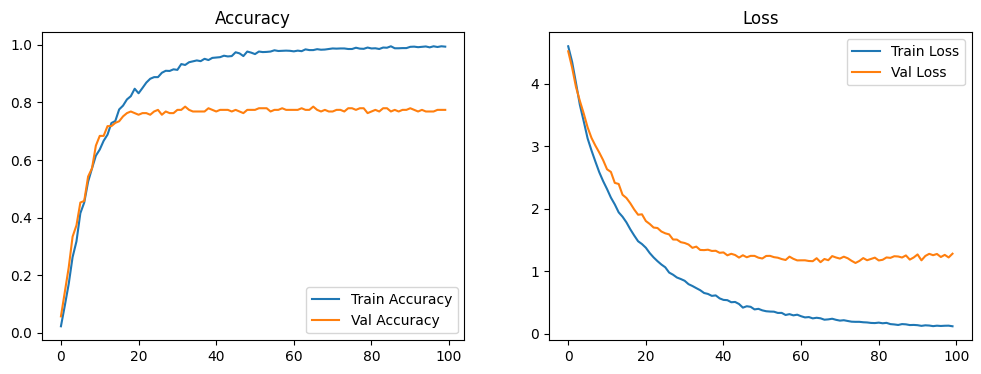

In [ ]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title('Accuracy')

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Loss')

plt.show()

## Visualisasi Hasil Pelatihan CNN dan LSTM

## Classification Report

In [ ]:
# Prediksi data testing
Y_pred = model_cnn_lstm.predict(X_test)
Y_pred_classes = np.argmax(Y_pred, axis=1)
Y_true = np.argmax(Y_test, axis=1)

# Label kelas
class_names = sorted(os.listdir('data/hands'))

print("=== Classification Report ===")
print(classification_report(
    Y_true,
    Y_pred_classes,
    target_names=class_names
))

14/14 ━━━━━━━━━━━━━━━━━━━━ 4s 245ms/step
=== Classification Report ===
              precision    recall  f1-score   support

  akhiran-an       0.50      0.50      0.50         4
   akhiran-i       0.40      0.40      0.40         5
 akhiran-kan       0.80      1.00      0.89         4
 akhiran-man       0.43      0.75      0.55         4
 akhiran-nya       0.50      0.60      0.55         5
  akhiran-ti       1.00      0.75      0.86         4
 akhiran-wan       1.00      0.60      0.75         5
akhiran-wati       1.00      0.40      0.57         5
         apa       1.00      0.80      0.89         5
  awalan-ber       0.67      0.50      0.57         4
   awalan-di       0.57      0.80      0.67         5
   awalan-ke       0.80      1.00      0.89         4
   awalan-me       1.00      0.25      0.40         4
   awalan-pe       0.75      0.75      0.75         4
   awalan-se       0.75      0.75      0.75         4
  awalan-ter       0.50      0.80      0.62         5
        ba

In [ ]:
cm = confusion_matrix(Y_true, Y_pred_classes)
for i in range(cm.shape[0]):

    TP = cm[i, i]

    FN = np.sum(cm[i, :]) - TP

    FP = np.sum(cm[:, i]) - TP

    TN = np.sum(cm) - (TP + FP + FN)

    print(f"Kelas {i}")
    print(f"TP={TP}")
    print(f"TN={TN}")
    print(f"FP={FP}")
    print(f"FN={FN}")
    print("----------------")

Kelas 0
TP=2
TN=435
FP=2
FN=2
----------------
Kelas 1
TP=2
TN=433
FP=3
FN=3
----------------
Kelas 2
TP=4
TN=436
FP=1
FN=0
----------------
Kelas 3
TP=3
TN=433
FP=4
FN=1
----------------
Kelas 4
TP=3
TN=433
FP=3
FN=2
----------------
Kelas 5
TP=3
TN=437
FP=0
FN=1
----------------
Kelas 6
TP=3
TN=436
FP=0
FN=2
----------------
Kelas 7
TP=2
TN=436
FP=0
FN=3
----------------
Kelas 8
TP=4
TN=436
FP=0
FN=1
----------------
Kelas 9
TP=2
TN=436
FP=1
FN=2
----------------
Kelas 10
TP=4
TN=433
FP=3
FN=1
----------------
Kelas 11
TP=4
TN=436
FP=1
FN=0
----------------
Kelas 12
TP=1
TN=437
FP=0
FN=3
----------------
Kelas 13
TP=3
TN=436
FP=1
FN=1
----------------
Kelas 14
TP=3
TN=436
FP=1
FN=1
----------------
Kelas 15
TP=4
TN=432
FP=4
FN=1
----------------
Kelas 16
TP=4
TN=435
FP=2
FN=0
----------------
Kelas 17
TP=2
TN=437
FP=0
FN=2
----------------
Kelas 18
TP=4
TN=436
FP=0
FN=1
----------------
Kelas 19
TP=4
TN=436
FP=0
FN=1
----------------
Kelas 20
TP=4
TN=437
FP=0
FN=0
----------------
Ke